# Unione immagini

In [26]:
from PIL import Image

# 1. Carica le due immagini
img_top = Image.open("FIG2_AB.png")
img_bottom = Image.open("FIG2_C.png")

# 2. Calcola le dimensioni della nuova immagine combinata
# La larghezza sarà la maggiore tra le due, l'altezza sarà la somma delle due
new_width = max(img_top.width, img_bottom.width)
new_height = img_top.height + img_bottom.height

# 3. Crea una nuova "tela" vuota con sfondo bianco
new_img = Image.new('RGB', (new_width, new_height), (255, 255, 255))

# 4. Incolla le immagini sulla tela
# L'immagine superiore va alle coordinate (0, 0)
new_img.paste(img_top, (0, 0))
# L'immagine inferiore va attaccata subito sotto la prima
new_img.paste(img_bottom, (0, img_top.height))

# 5. Salva il risultato finale
new_img.save("FIG2_Completa.png")
print("Immagini unite con successo! Il file 'FIG2_Completa.png' è pronto.")

Immagini unite con successo! Il file 'FIG2_Completa.png' è pronto.


Layout generato con successo e salvato come Pannello_FIG1_Composito.png!


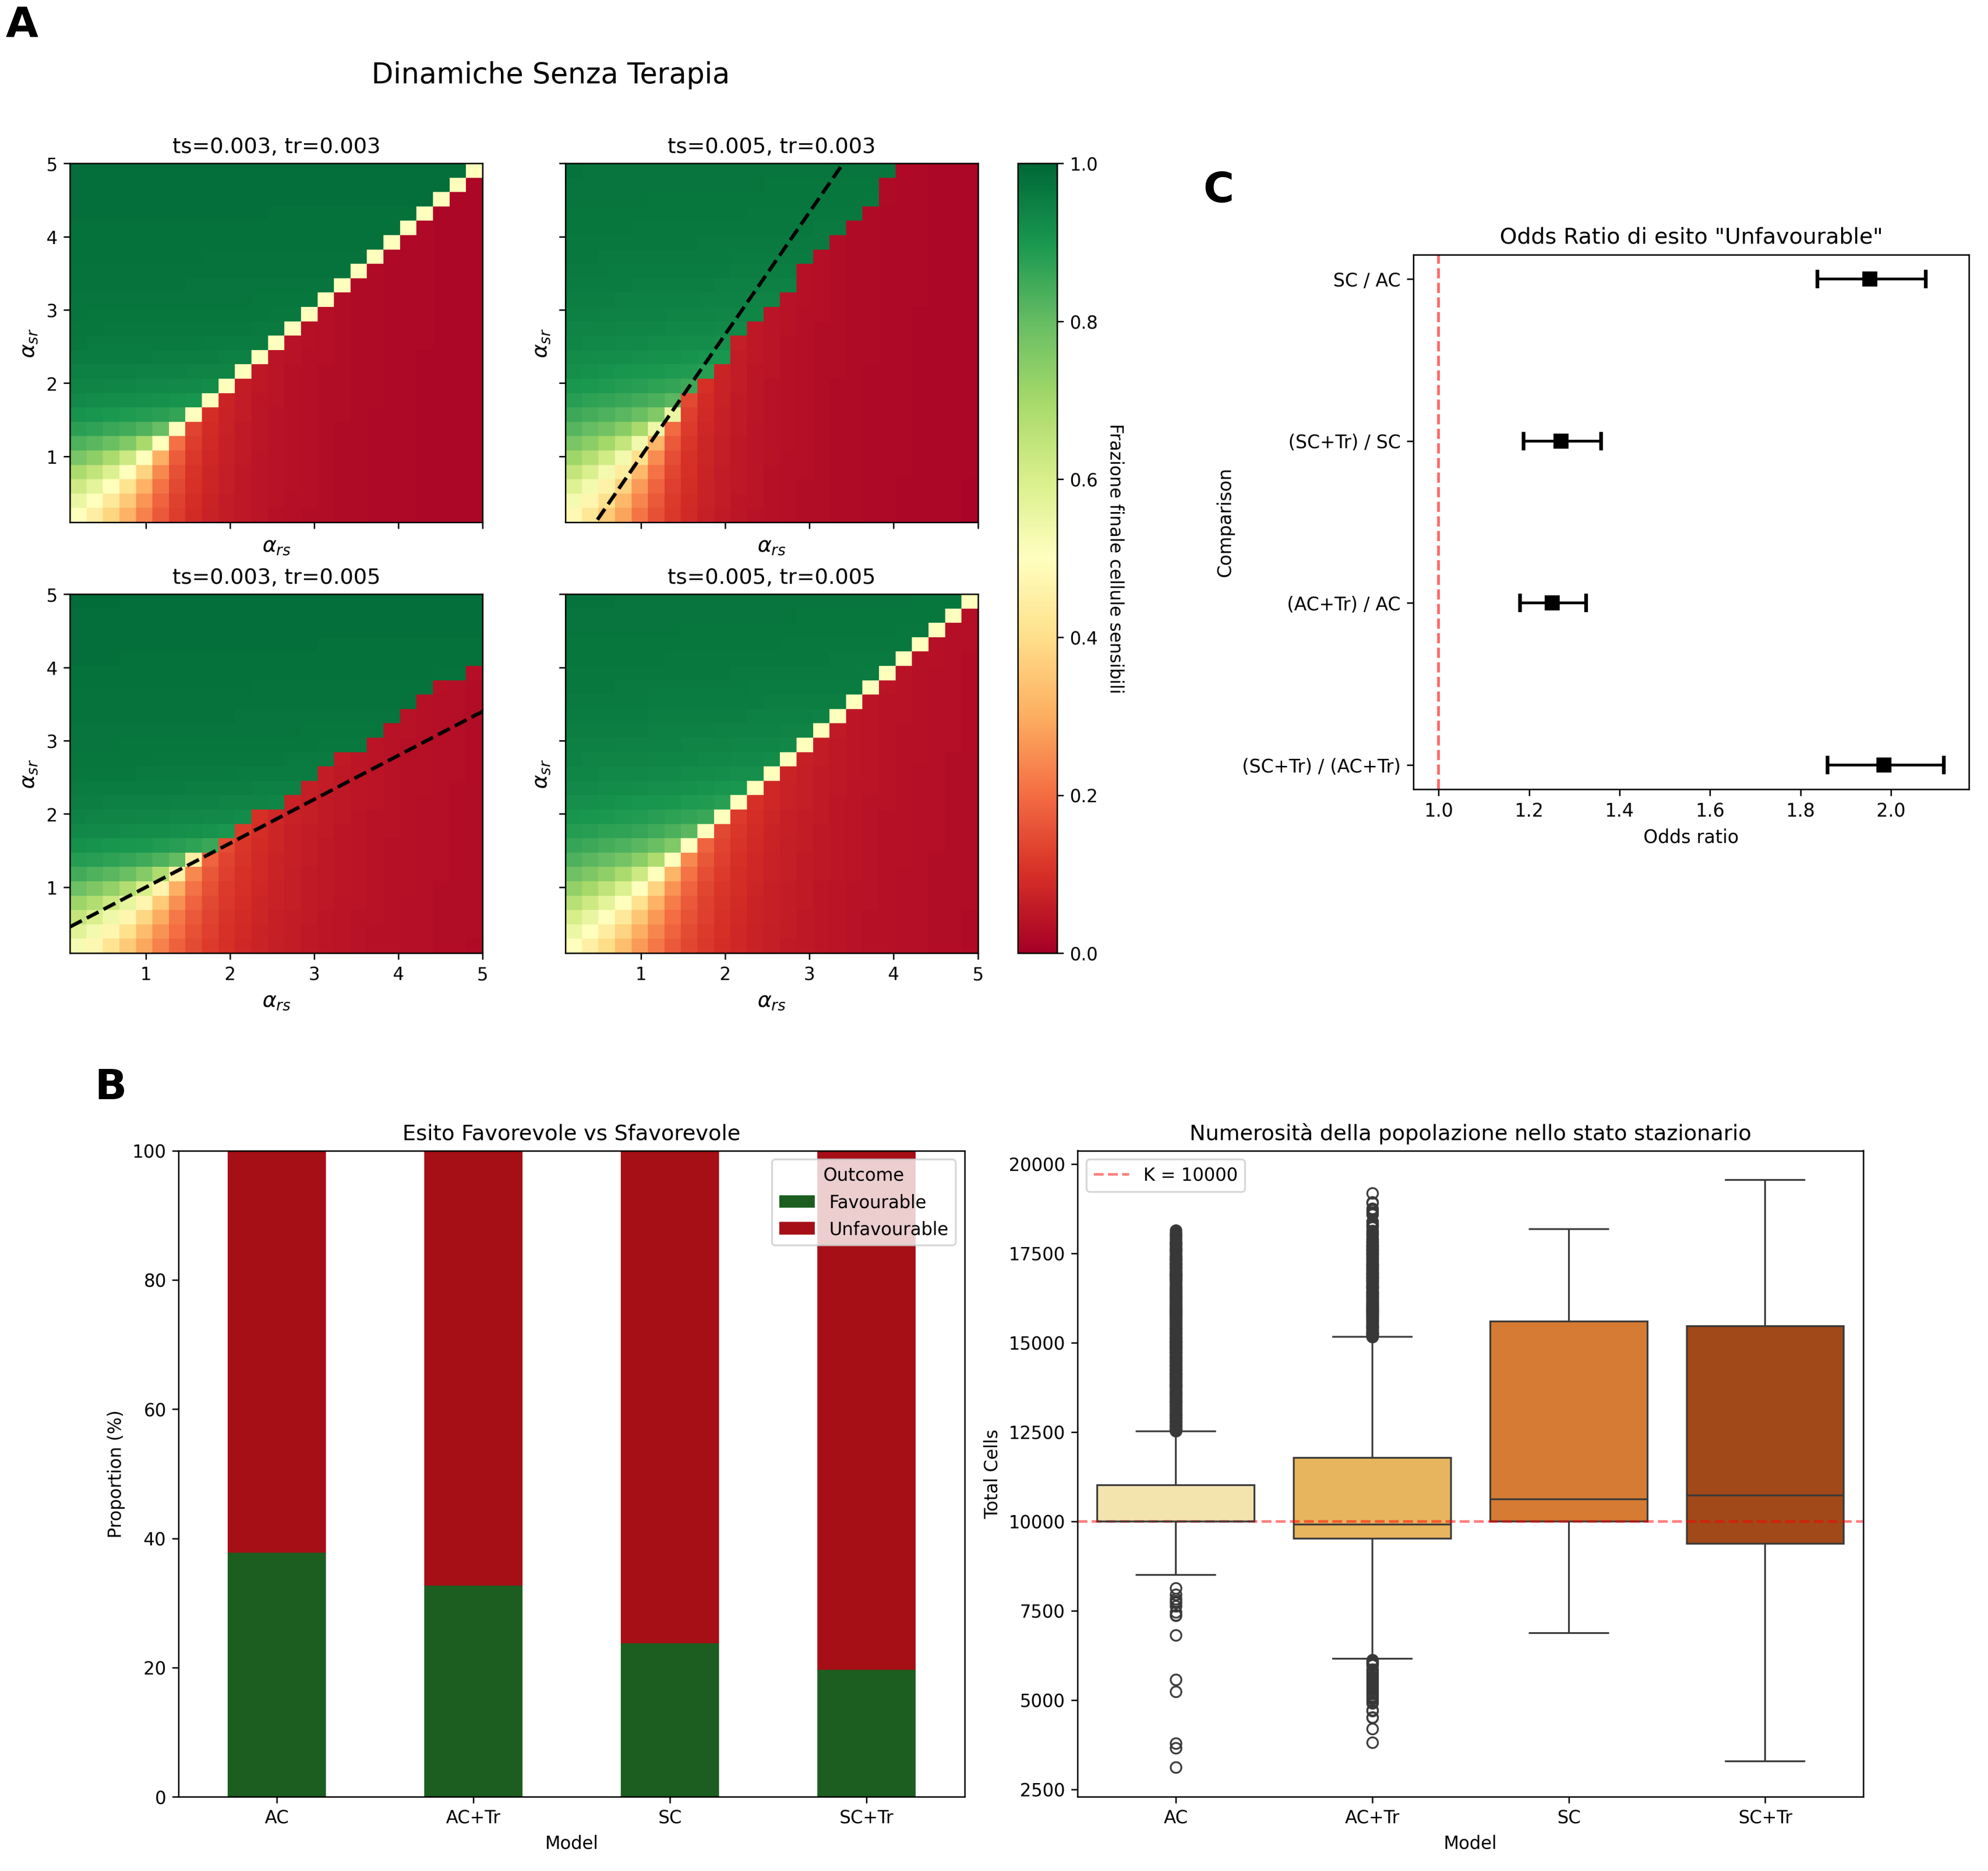

In [24]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image

# 1. Carica le immagini (assicurati che i nomi corrispondano ai tuoi file)
img_A = Image.open('figura1B.png')
img_B = Image.open('figura1A.png')
img_C = Image.open('figura1C.png')

# 2. Ottieni le dimensioni reali in pixel
w_A, h_A = img_A.size
w_B, h_B = img_B.size
w_C, h_C = img_C.size

# 3. Calcola le dimensioni totali della figura
# Larghezza = il valore massimo tra la larghezza di A e la somma delle larghezze di B e C
total_w = max(w_B + w_C, w_A)
# Altezza = l'altezza maggiore tra B e C, sommata all'altezza di A
total_h = max(h_B, h_C) + h_A

# Converti in pollici per matplotlib
fig_w, fig_h = total_w / 100, total_h / 100
fig = plt.figure(figsize=(fig_w, fig_h))

# 4. Definisci la griglia: 2 righe e 2 colonne
# La larghezza delle colonne si baserà su B e C.
gs = gridspec.GridSpec(2, 2, 
                       width_ratios=[w_B, w_C], 
                       height_ratios=[max(h_B, h_C), h_A], 
                       wspace=0.05, hspace=0.1) # hspace leggermente aumentato per far respirare le lettere

# 5. Posiziona l'immagine B (in alto a sinistra: riga 0, colonna 0)
ax_B = fig.add_subplot(gs[0, 0])
ax_B.imshow(img_B)
ax_B.axis('off')
ax_B.set_title('A', loc='left', fontsize=52, fontweight='bold', pad=15)

# 6. Posiziona l'immagine C (in alto a destra: riga 0, colonna 1)
ax_C = fig.add_subplot(gs[0, 1])
ax_C.imshow(img_C)
ax_C.axis('off')
ax_C.set_title('C', loc='left', fontsize=52, fontweight='bold', pad=15)

# 7. Posiziona l'immagine A (in basso)
# Usando gs[1, :] diciamo a Python di prendere la riga 1 e TUTTE (:) le colonne
ax_A = fig.add_subplot(gs[1, :])
ax_A.imshow(img_A)
ax_A.axis('off')
ax_A.set_title('B', loc='left', fontsize=52, fontweight='bold', pad=15)

# 8. Salva il pannello finale
nome_output = 'Pannello_FIG1_Composito.png'
plt.savefig(nome_output, dpi=300, bbox_inches='tight', pad_inches=0.05)
print(f"Layout generato con successo e salvato come {nome_output}!")

Layout salvato con successo come Pannello_FIG2_Asimmetrico.png!


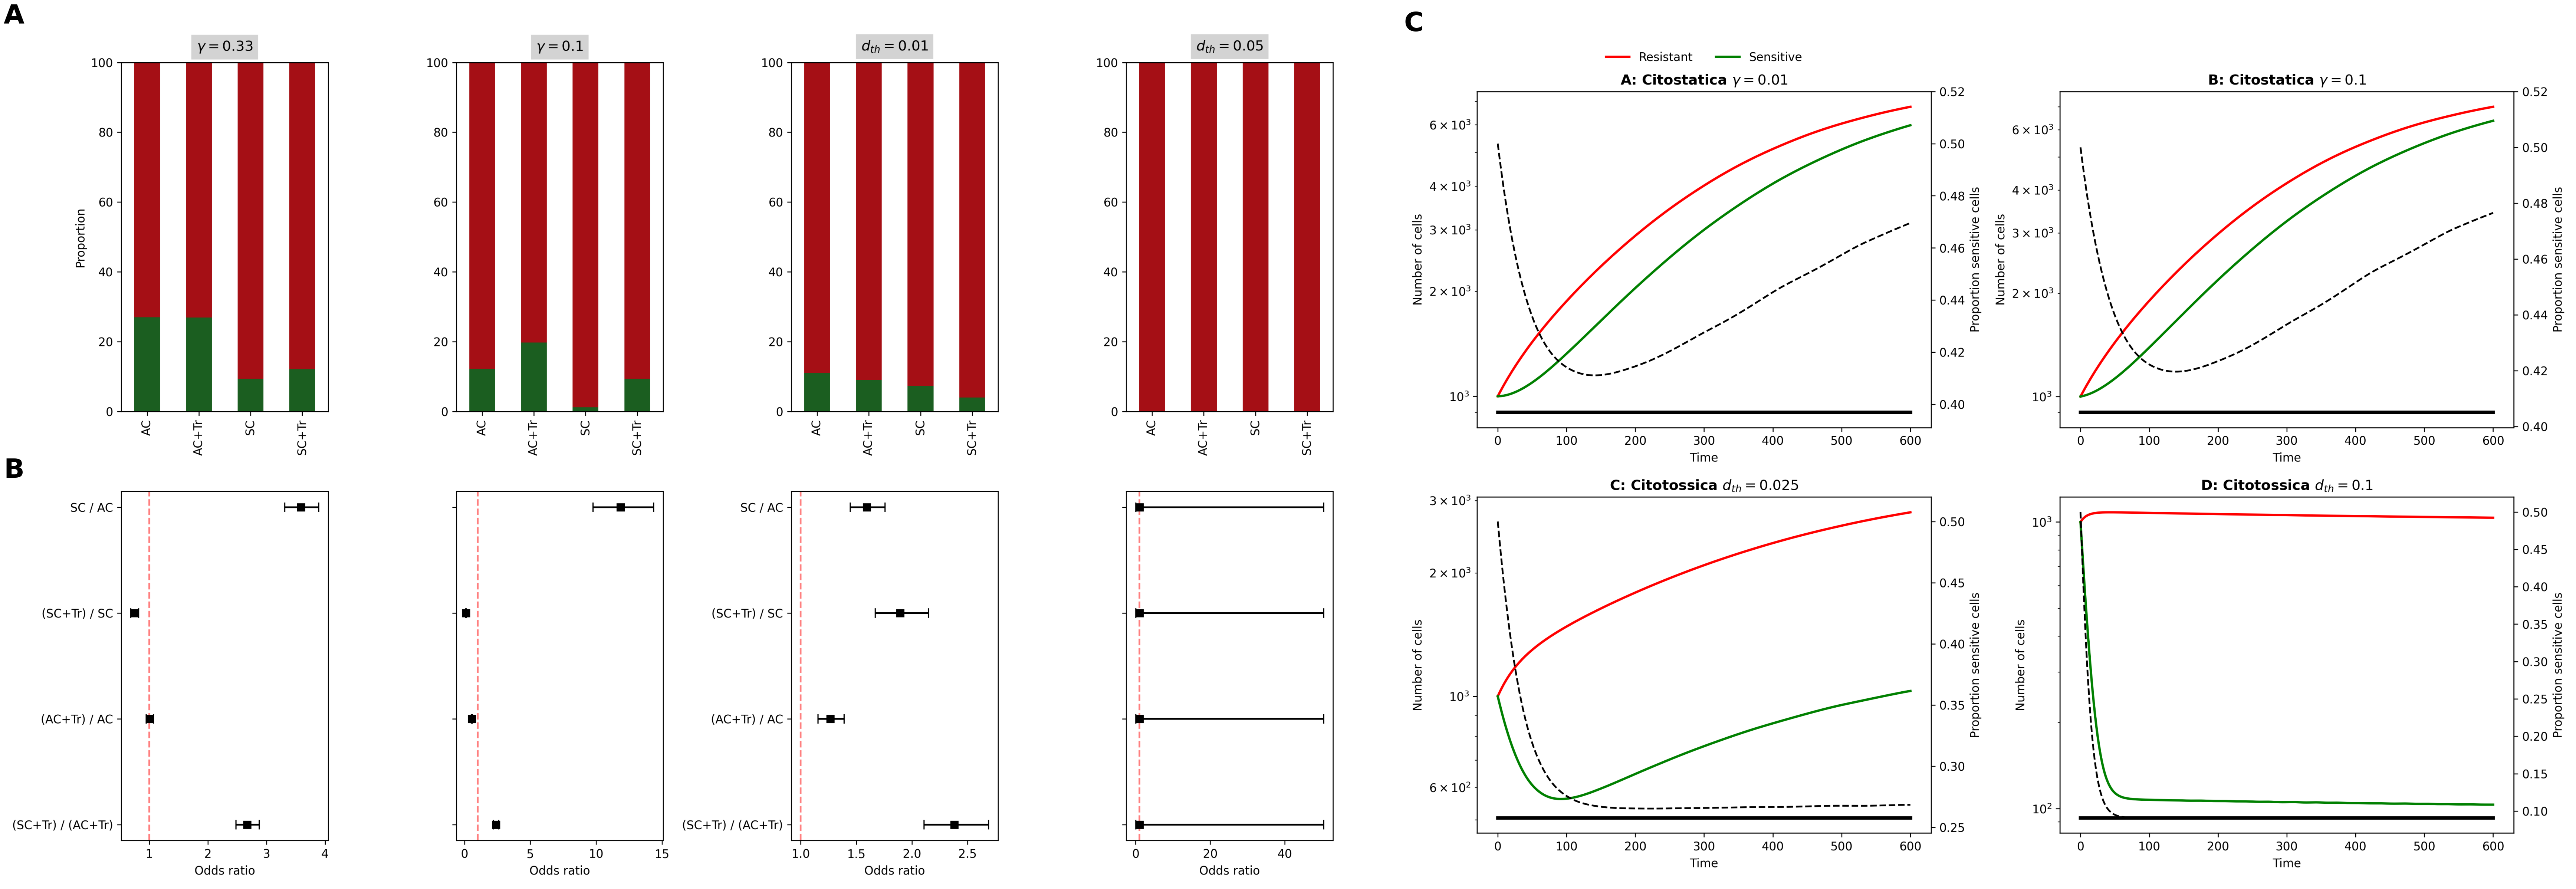

In [21]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image

# 1. Carica le immagini (assicurati che i nomi corrispondano esattamente ai file nella tua cartella)
img_A = Image.open('FIG2AB_solocolonne.png')
img_B = Image.open('FIG2AB_soloodds.png')
img_C = Image.open('figura2cd.png')

# 2. Ottieni le dimensioni reali in pixel per non distorcere nulla
w_A, h_A = img_A.size
w_B, h_B = img_B.size
w_C, h_C = img_C.size

# 3. Calcola le dimensioni totali del pannello asimmetrico
# Larghezza = la larghezza maggiore tra A e B (colonna sinistra) + la larghezza di C (colonna destra)
total_w = max(w_A, w_B) + w_C
# Altezza = la maggiore tra la somma delle altezze di A e B, e l'altezza di C
total_h = max(h_A + h_B, h_C)

# 4. Converti i pixel in pollici per matplotlib
fig_w, fig_h = total_w / 100, total_h / 100
fig = plt.figure(figsize=(fig_w, fig_h))

# 5. Definisci la griglia proporzionata alle dimensioni reali (2 righe, 2 colonne)
gs = gridspec.GridSpec(2, 2, 
                       width_ratios=[max(w_A, w_B), w_C], 
                       height_ratios=[h_A, h_B], 
                       wspace=0.05, hspace=0.05)

# 6. Posiziona l'immagine A (colonna di sinistra, riga in alto)
ax_A = fig.add_subplot(gs[0, 0])
ax_A.imshow(img_A)
ax_A.axis('off') # Nasconde gli assi
ax_A.set_title('A', loc='left', fontsize=52, fontweight='bold', pad=15)

# 7. Posiziona l'immagine B (colonna di sinistra, riga in basso)
ax_B = fig.add_subplot(gs[1, 0])
ax_B.imshow(img_B)
ax_B.axis('off')
ax_B.set_title('B', loc='left', fontsize=52, fontweight='bold', pad=15)

# 8. Posiziona l'immagine C (colonna di destra, espansa su entrambe le righe con ':')
ax_C = fig.add_subplot(gs[:, 1])
ax_C.imshow(img_C)
ax_C.axis('off')
ax_C.set_title('C', loc='left', fontsize=52, fontweight='bold', pad=15)

# 9. Salva il pannello finale ad altissima risoluzione
nome_output = 'Pannello_FIG2_Asimmetrico.png'
plt.savefig(nome_output, dpi=300, bbox_inches='tight', pad_inches=0.05)
print(f"Layout salvato con successo come {nome_output}!")

Layout a dimensioni reali salvato con successo!


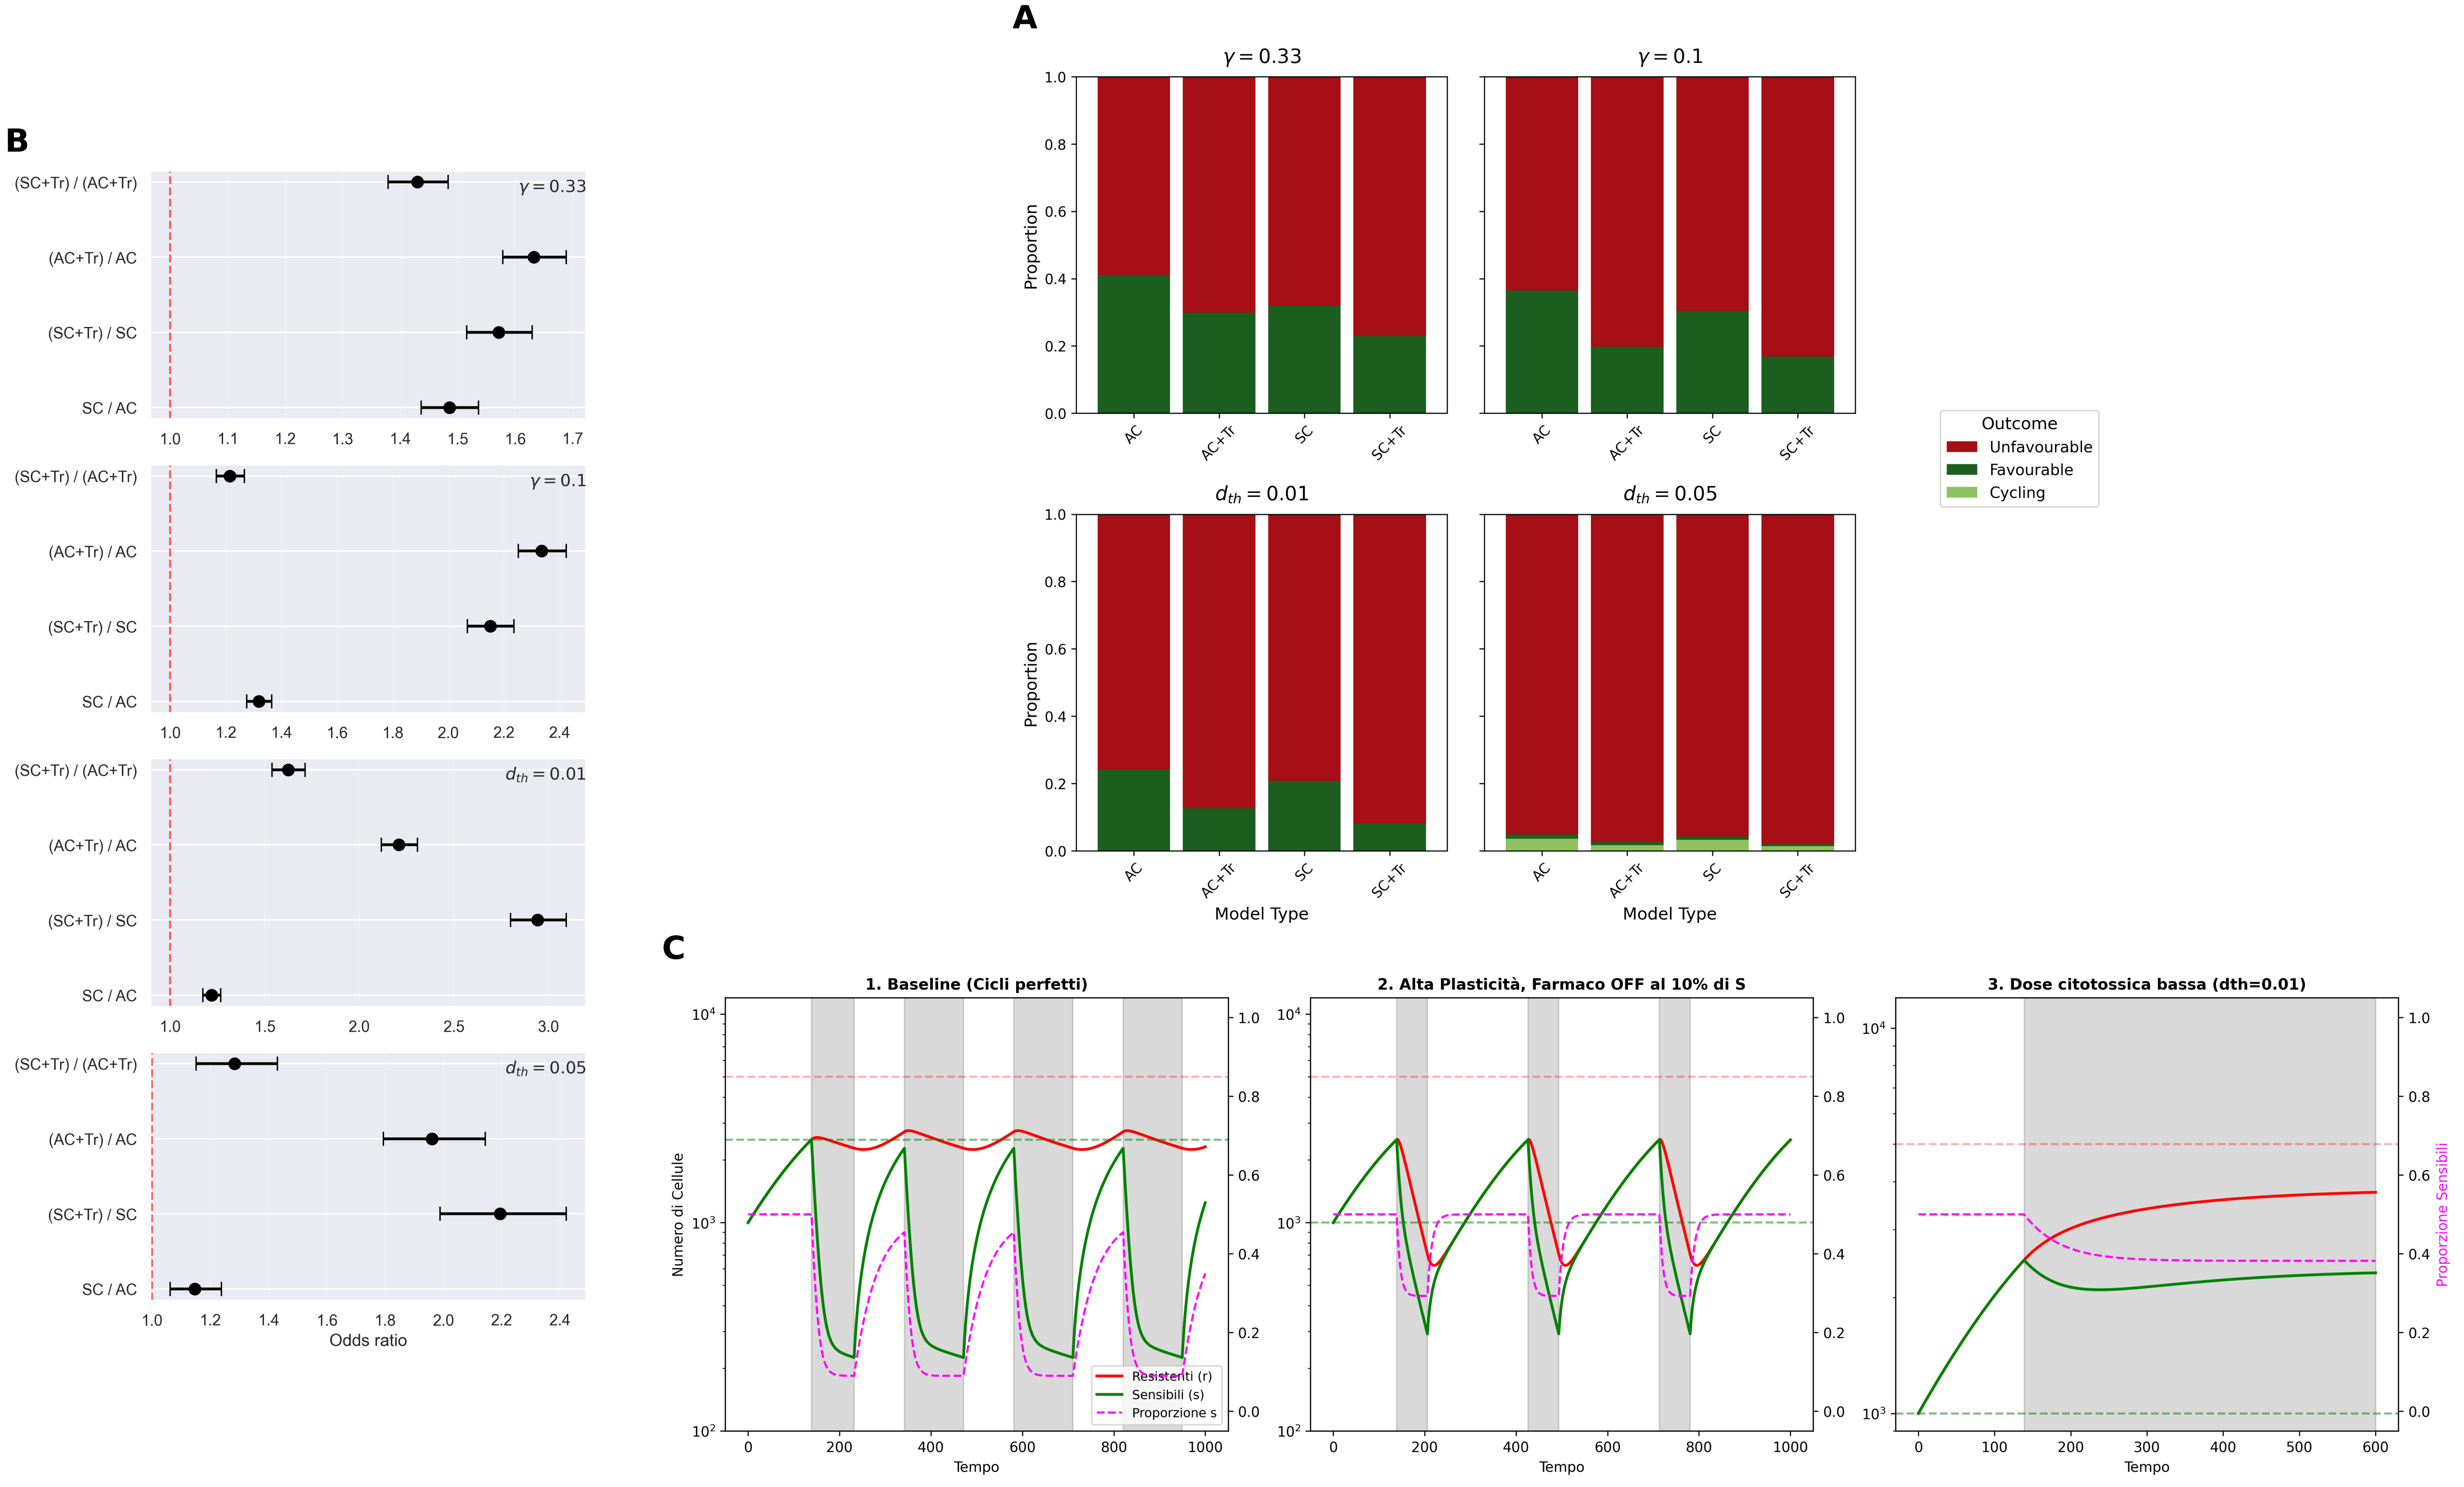

In [18]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image

# 1. Carica le immagini originali separate (sostituisci con i nomi reali dei tuoi file)
img_A = Image.open('FIG3A.png')
img_B = Image.open('FIG3B.png')
img_C = Image.open('FIG2CD_tesi.png')

# 2. Ottieni le dimensioni reali di ciascuna immagine in pixel
w_A, h_A = img_A.size
w_B, h_B = img_B.size
w_C, h_C = img_C.size

# 3. Calcola le dimensioni totali del pannello per il layout asimmetrico
# Larghezza totale = larghezza di B + larghezza massima tra A e C
total_w = w_B + max(w_A, w_C)
# Altezza totale = altezza massima tra B e (altezza A + altezza C)
total_h = max(h_B, h_A + h_C)

# 4. Converti i pixel in pollici per matplotlib
# Dividiamo per un valore arbitrario (es. 100 DPI) per calcolare la proporzione corretta
fig_w, fig_h = total_w / 100, total_h / 100
fig = plt.figure(figsize=(fig_w, fig_h))

# 5. Definisci GridSpec con i rapporti di larghezza e altezza proporzionali alle dimensioni reali
# wspace e hspace controllano lo spazio tra le immagini
gs = gridspec.GridSpec(2, 2, width_ratios=[w_B, max(w_A, w_C)], height_ratios=[h_A, h_C], wspace=0.05, hspace=0.05)

# 6. Assegna le immagini alle posizioni nella griglia senza usare aspect='auto'
# aspect='equal' è il default per imshow, e preserva le proporzioni originali
ax_B = fig.add_subplot(gs[:, 0])
ax_B.imshow(img_B)
ax_B.axis('off')
ax_B.set_title('B', loc='left', fontsize=52, fontweight='bold', pad=15)

ax_A = fig.add_subplot(gs[0, 1])
ax_A.imshow(img_A)
ax_A.axis('off')
ax_A.set_title('A', loc='left', fontsize=52, fontweight='bold', pad=15)

ax_C = fig.add_subplot(gs[1, 1])
ax_C.imshow(img_C)
ax_C.axis('off')
ax_C.set_title('C', loc='left', fontsize=52, fontweight='bold', pad=15)

# 7. Salva l'immagine finale ad alta risoluzione
# bbox_inches='tight' e pad_inches=0 riducono al minimo i bordi esterni
plt.savefig('FIG3.png', dpi=300, bbox_inches='tight', pad_inches=0.05)
print("Layout a dimensioni reali salvato con successo!")

Nuovo layout asimmetrico salvato con successo!


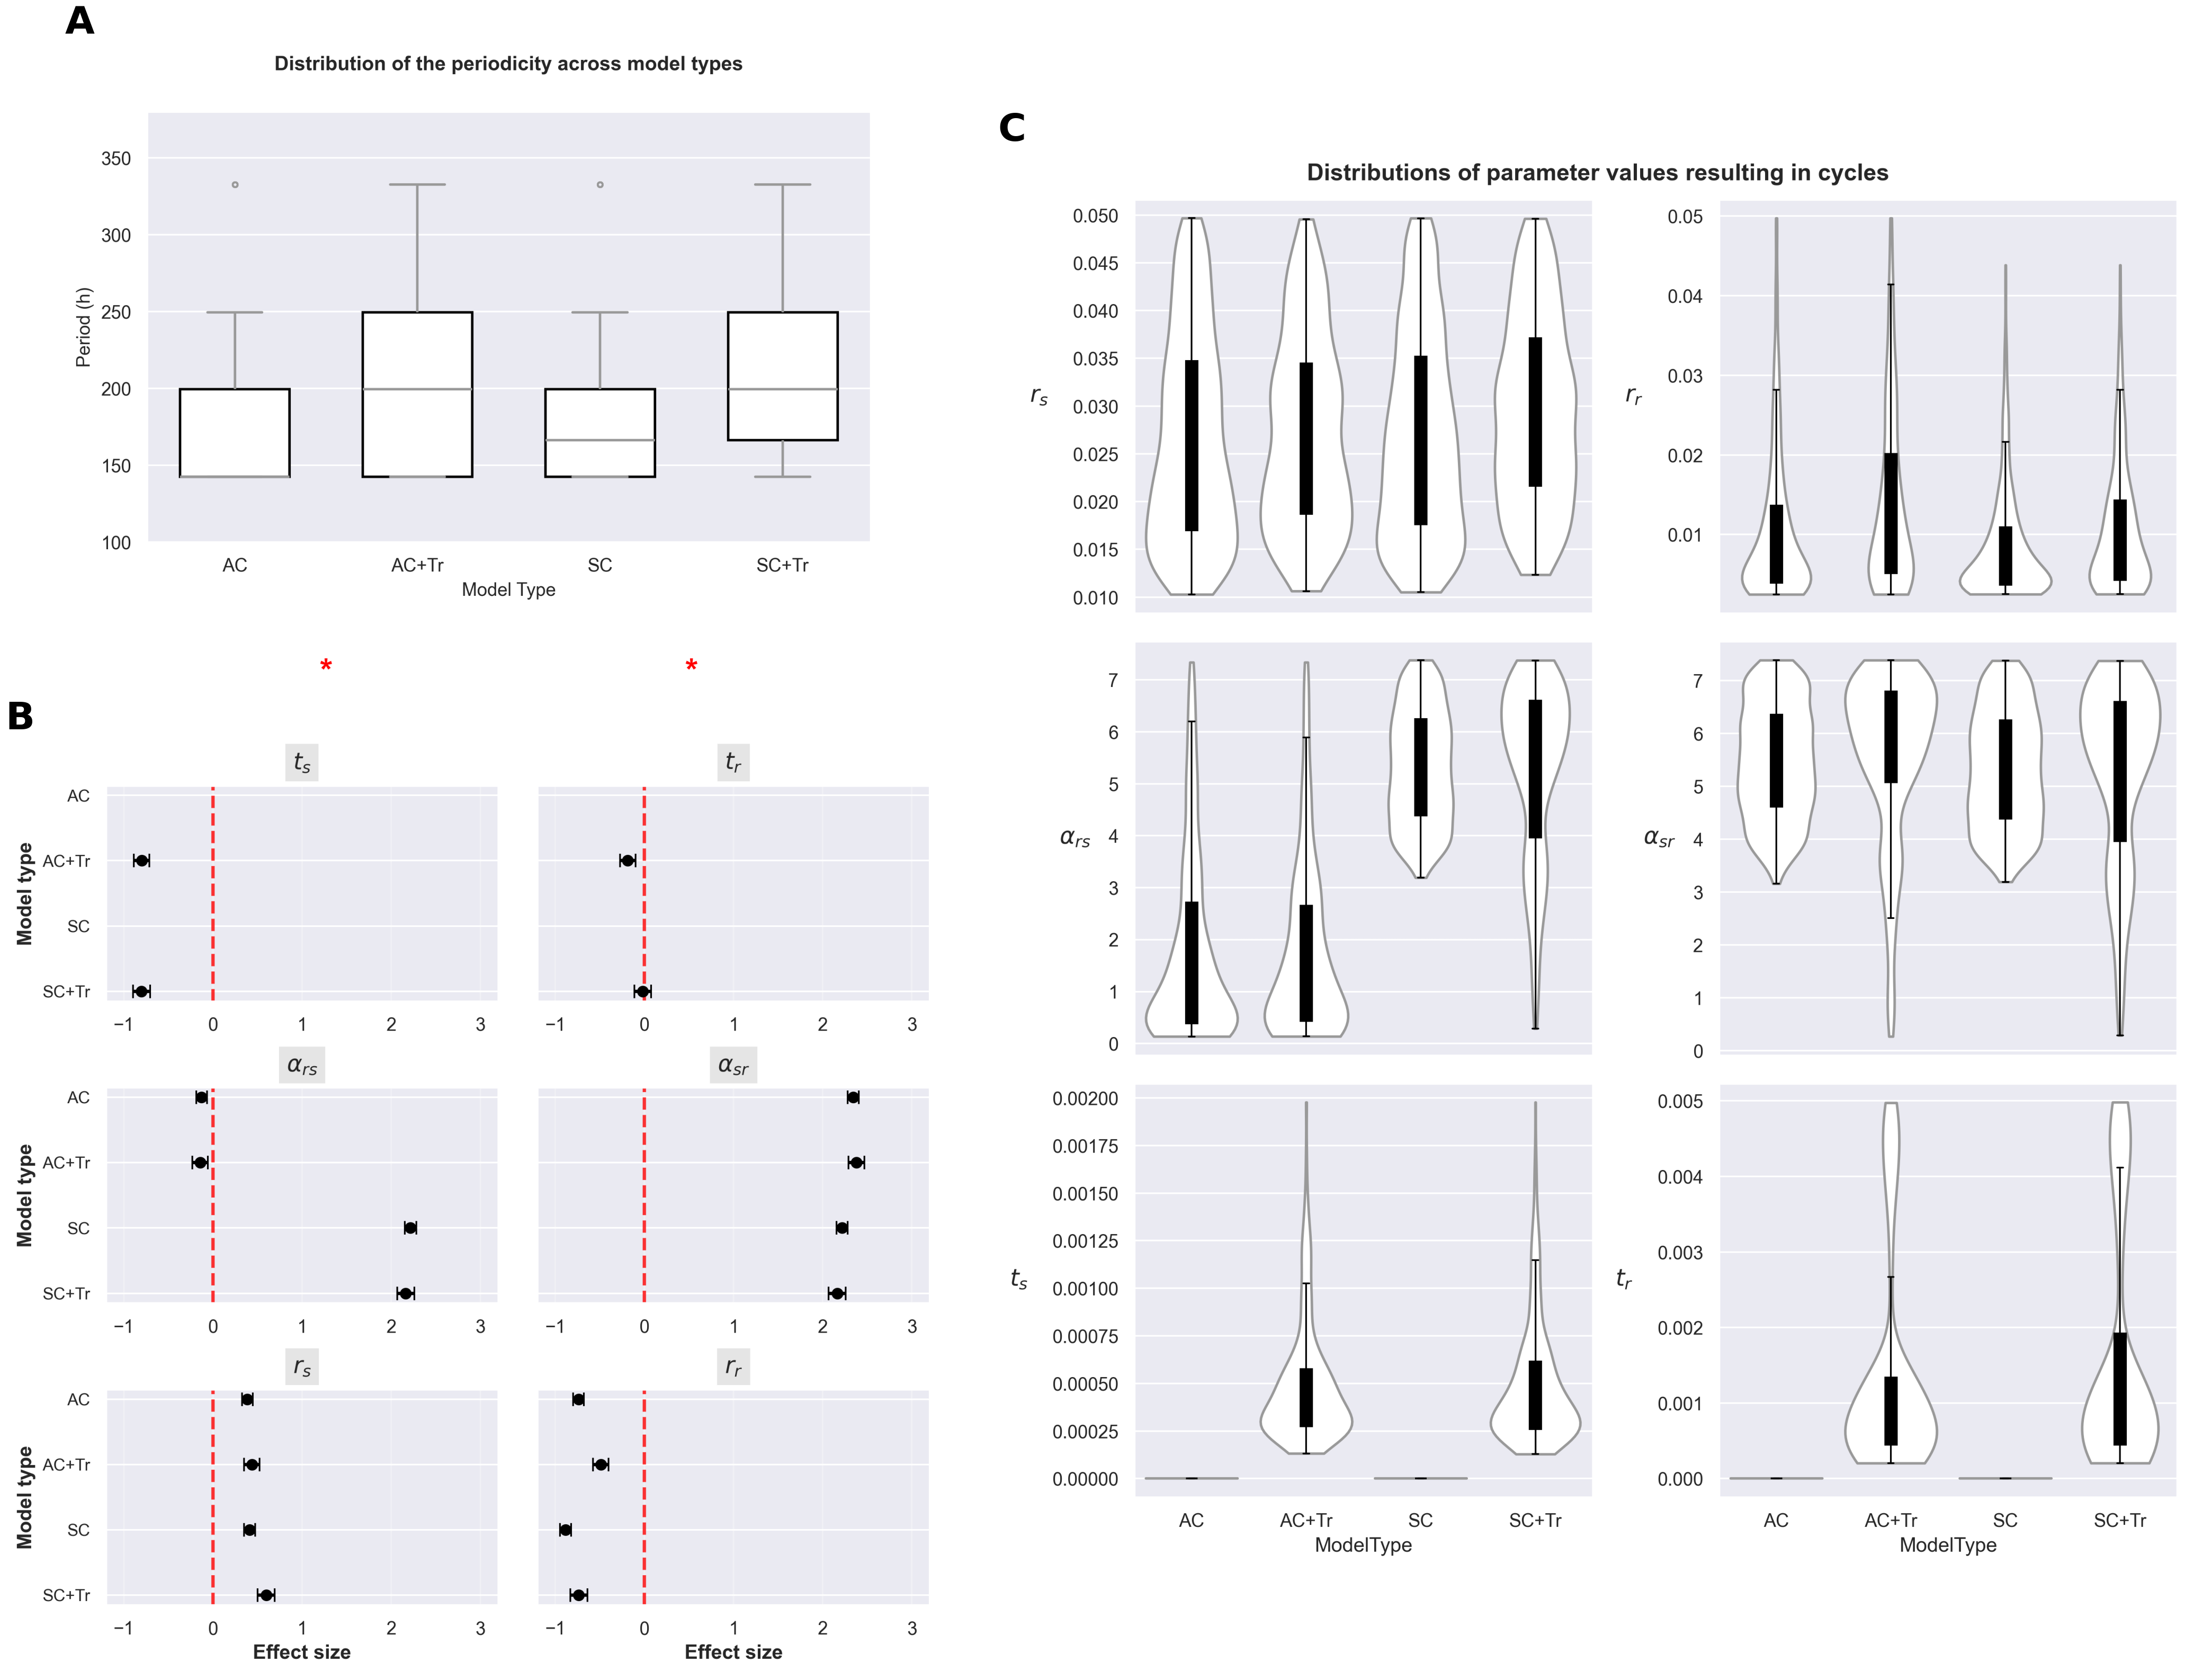

In [17]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image

# 1. Carica le immagini
img_A = Image.open('FIG4A.png')
img_B = Image.open('FIG4B.png')
img_C = Image.open('FIG4C.png')

# 2. Ottieni le dimensioni reali in pixel
w_A, h_A = img_A.size
w_B, h_B = img_B.size
w_C, h_C = img_C.size

# 3. Calcola le dimensioni totali del pannello per il nuovo layout
# Larghezza = la larghezza maggiore tra A e B (colonna sinistra) + la larghezza di C (colonna destra)
total_w = max(w_A, w_B) + w_C
# Altezza = la maggiore tra la somma delle altezze di A e B, e l'altezza di C
total_h = max(h_A + h_B, h_C)

# 4. Converti i pixel in pollici per matplotlib
fig_w, fig_h = total_w / 100, total_h / 100
fig = plt.figure(figsize=(fig_w, fig_h))

# 5. Definisci la griglia proporzionata alle dimensioni reali (2 righe, 2 colonne)
# La colonna di sinistra prende la larghezza massima tra A e B, quella di destra la larghezza di C.
# Le righe prendono le altezze rispettive di A e B.
gs = gridspec.GridSpec(2, 2, 
                       width_ratios=[max(w_A, w_B), w_C], 
                       height_ratios=[h_A, h_B], 
                       wspace=0.05, hspace=0.05)

# 6. Posiziona l'immagine A (colonna di sinistra, riga in alto)
ax_A = fig.add_subplot(gs[0, 0])
ax_A.imshow(img_A)
ax_A.axis('off')
ax_A.set_title('A', loc='left', fontsize=52, fontweight='bold', pad=15)

# 7. Posiziona l'immagine B (colonna di sinistra, riga in basso)
ax_B = fig.add_subplot(gs[1, 0])
ax_B.imshow(img_B)
ax_B.axis('off')
ax_B.set_title('B', loc='left', fontsize=52, fontweight='bold', pad=15)

# 8. Posiziona l'immagine C (colonna di destra, occupa tutte le righe con ':')
ax_C = fig.add_subplot(gs[:, 1])
ax_C.imshow(img_C)
ax_C.axis('off')
ax_C.set_title('C', loc='left', fontsize=52, fontweight='bold', pad=15)

# 9. Salva il pannello finale ad alta risoluzione
plt.savefig('FIG4.png', dpi=300, bbox_inches='tight', pad_inches=0.05)
print("Nuovo layout asimmetrico salvato con successo!")

L'immagine combinata è stata salvata come 'figura_completa_affiancata.png'.


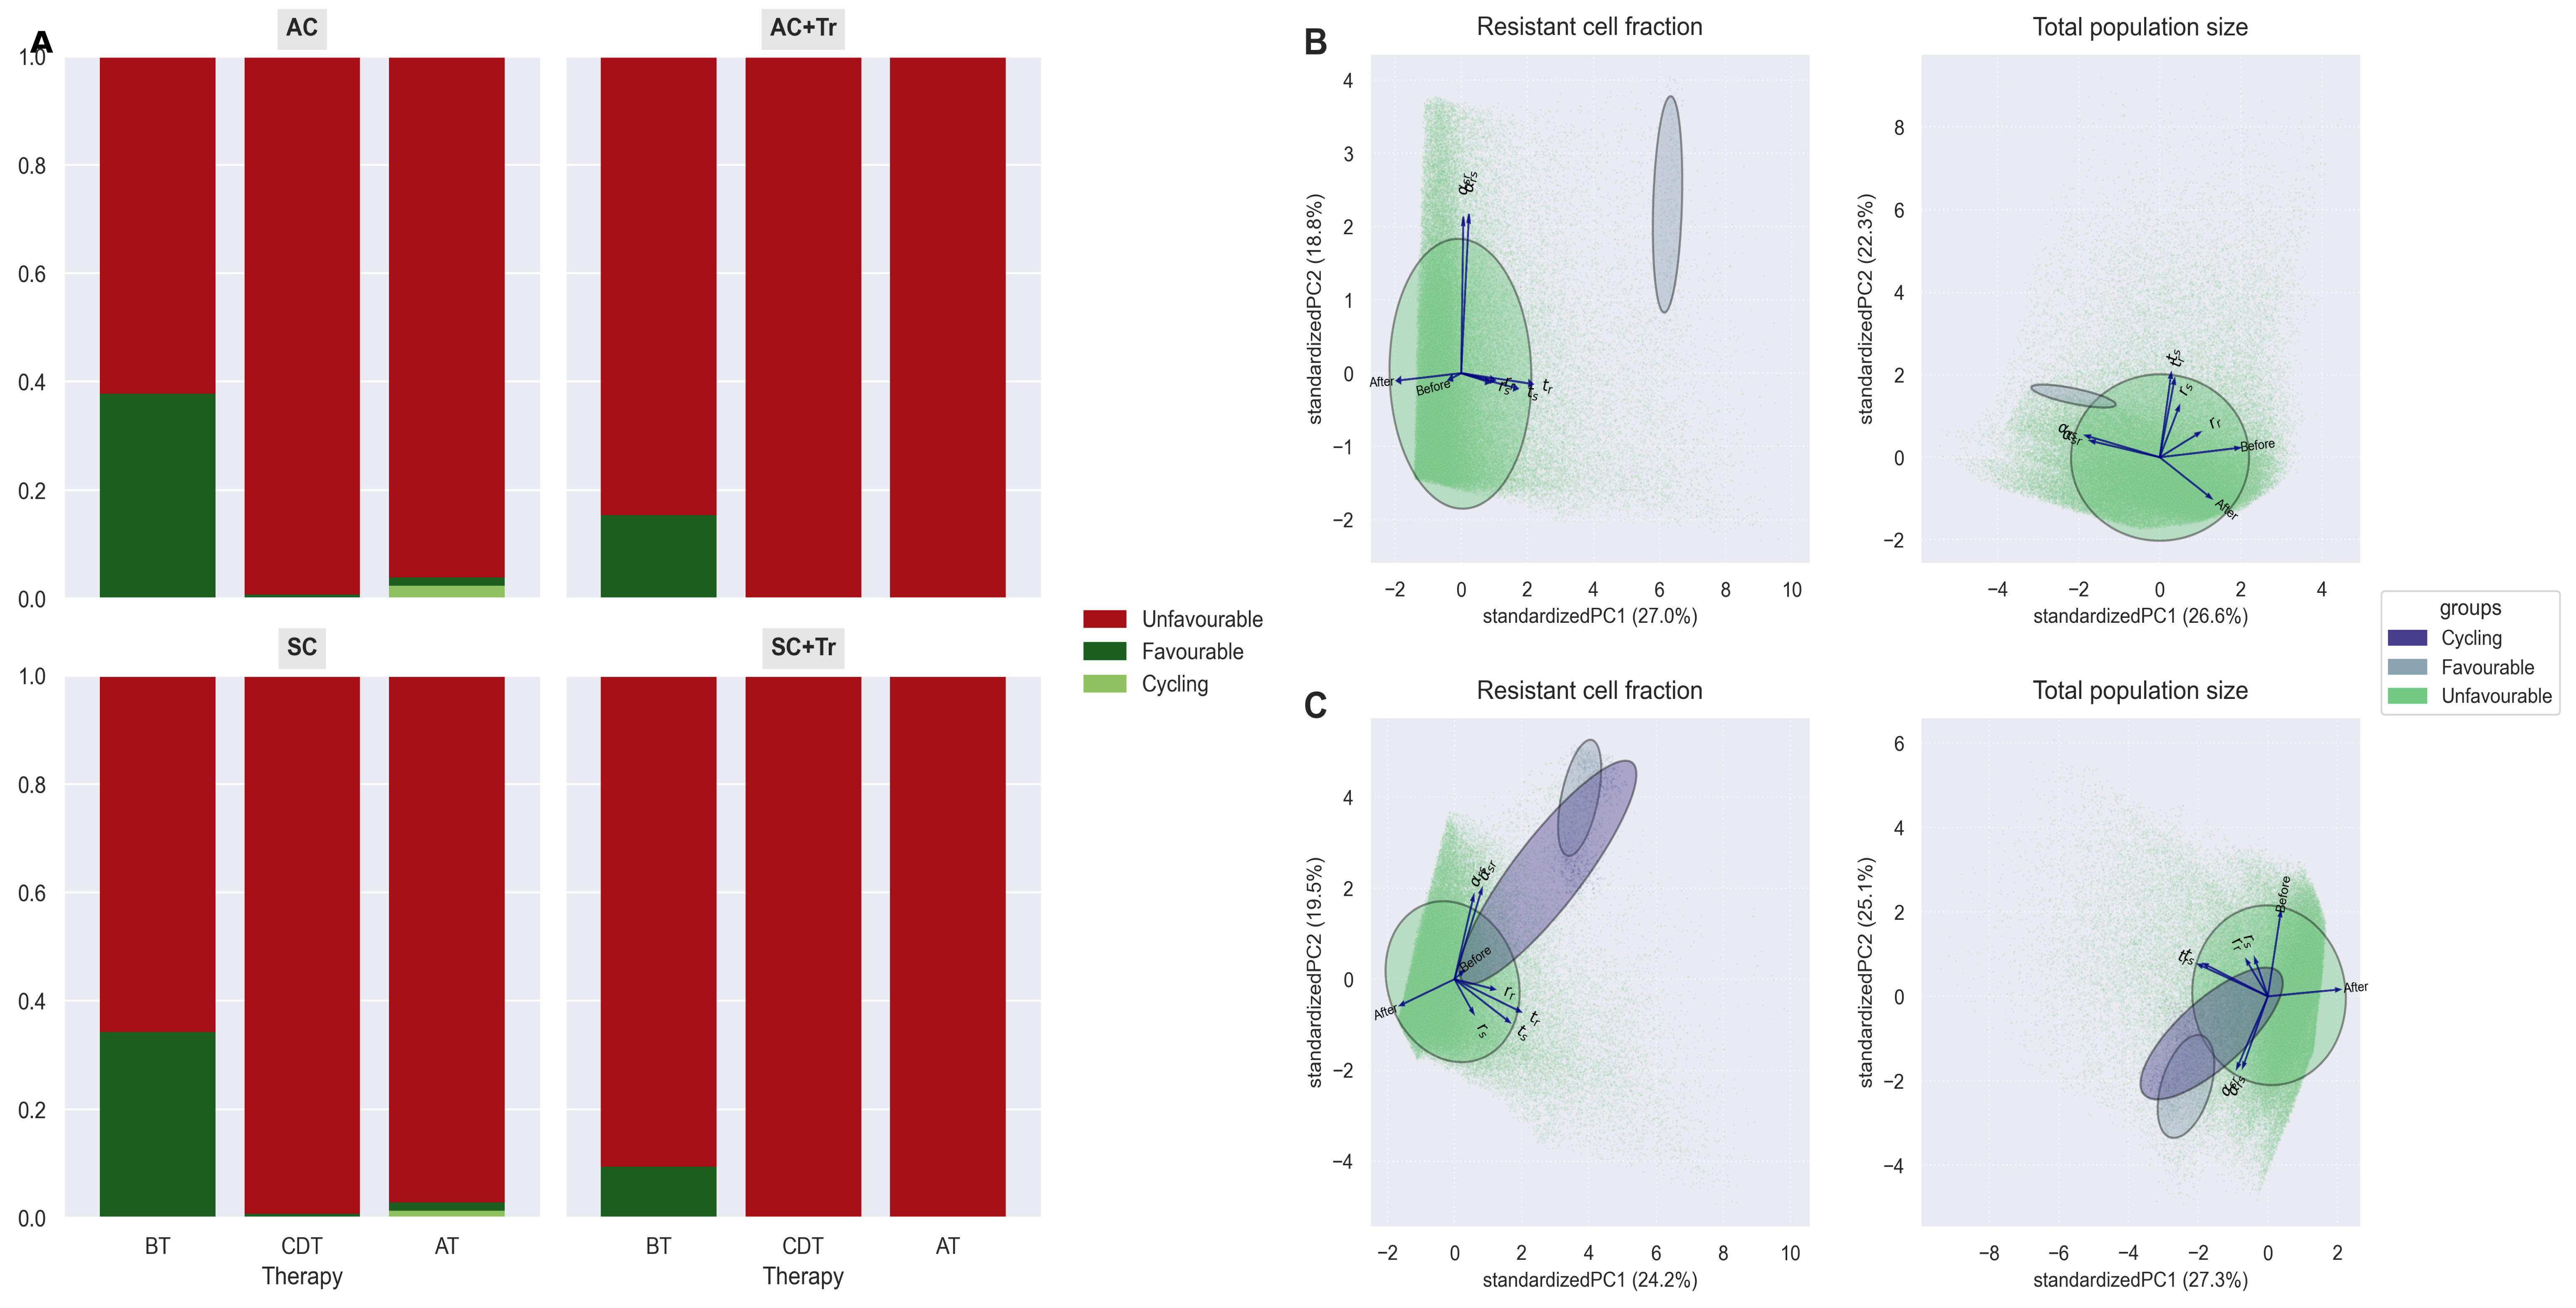

In [27]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image
import os

# Nomi dei file delle immagini (assicurati che siano nella stessa directory dello script)
file_image_1 = 'FIG5A.png'
file_image_2 = 'FIG5B.png'

# Controlla che i file esistano
if not os.path.exists(file_image_1) or not os.path.exists(file_image_2):
    print(f"Errore: Uno o entrambi i file ({file_image_1}, {file_image_2}) non sono stati trovati.")
    exit()

# Carica le immagini utilizzando PIL per ottenere le dimensioni (per un calcolo automatico della dimensione della figura)
img1_data = Image.open(file_image_1)
img2_data = Image.open(file_image_2)

# Ottieni le dimensioni delle immagini
width1, height1 = img1_data.size
width2, height2 = img2_data.size

# Calcola una dimensione della figura bilanciata per affiancare le immagini
# (Regola questo valore se desideri che la figura sia più grande o più piccola)
scale_factor = 0.01  # Fattore di scala per convertire i pixel in pollici di Matplotlib
total_width = (width1 + width2) * scale_factor
max_height = max(height1, height2) * scale_factor
fig_size = (total_width + 2, max_height + 2) # Aggiunge spazio extra per i margini

# Crea la figura e i subplots
fig, axes = plt.subplots(1, 2, figsize=fig_size)

# Visualizza la prima immagine e aggiunge l'etichetta 'A'
axes[0].imshow(img1_data, aspect='auto') # aspect='auto' aiuta a riempire il subplot se le altezze sono diverse
axes[0].axis('off') # Nasconde gli assi

# Testo per l'etichetta 'A'. Posizionamento in alto a sinistra (0.02, 0.98 in coordinate transAxes)
# transAxes posiziona il testo in base alle dimensioni del subplot, non ai dati.
axes[0].text(0.02, 0.98, 'A', transform=axes[0].transAxes, fontsize=52, fontweight='bold', va='top', ha='left', color='black')

# Visualizza la seconda immagine (etichette già presenti)
axes[1].imshow(img2_data, aspect='auto')
axes[1].axis('off') # Nasconde gli assi

# Regola il layout per evitare sovrapposizioni e spazi vuoti
plt.tight_layout()

# Salva l'immagine finale combinata
final_image_name = 'figura_completa_affiancata.png'
plt.savefig(final_image_name, dpi=300) # Salva con alta risoluzione (300 dpi)

print(f"L'immagine combinata è stata salvata come '{final_image_name}'.")

# Mostra l'immagine combinata (opzionale, se si esegue in un ambiente con interfaccia grafica)
# plt.show()